In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sid321axn/malicious-urls-dataset/malicious_phish.csv


In [2]:
import pandas as pd
import numpy as np
import re
import ipaddress
import math
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sid321axn/malicious-urls-dataset/malicious_phish.csv')
df = df.dropna(subset=['url', 'type']).reset_index(drop=True)
df['type'] = df['type'].str.lower().str.strip()

print("Shape:", df.shape)
df.head()

Shape: (651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

type
benign        65.74
defacement    14.81
phishing      14.45
malware        4.99
Name: proportion, dtype: float64


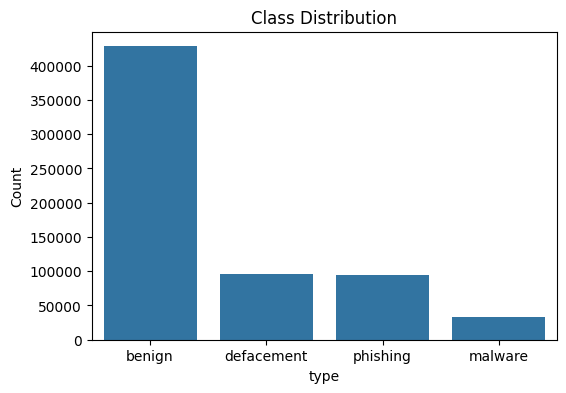

In [4]:
print(df['type'].value_counts())
print()
print(df['type'].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

In [5]:
SUSPICIOUS_WORDS = [
    "login", "verify", "secure", "account", "update",
    "password", "signin", "bank", "confirm", "click",
    "paypal", "webscr", "ebay", "suspend", "limited"
]

MALICIOUS_EXTENSIONS = ['.exe', '.zip', '.scr', '.bat', '.js', '.jar', '.php', '.apk']

IP_PATTERN = re.compile(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}')


def shannon_entropy(s):
    """Measures randomness of the string. Higher = more random/obfuscated."""
    if not s:
        return 0.0
    prob = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in prob)


def extract_features(url):
    url = str(url)
    url_lower = url.lower()

    # --- Safe parsing: some URLs are malformed (e.g. bad IPv6 brackets) ---
    try:
        parsed = urlparse(url if '://' in url else 'http://' + url)
        domain = parsed.netloc.lower()
        path = parsed.path
        query = parsed.query
    except ValueError:
        # Fallback: treat whole string as domain-less, can't parse properly
        domain = ""
        path = ""
        query = ""

    # --- IP analysis (enriched, fixes the dominance bug) ---
    ip_match = IP_PATTERN.search(url)
    has_ip = int(bool(ip_match))
    is_private_ip = 0
    is_public_ip = 0
    if ip_match:
        try:
            ip_obj = ipaddress.ip_address(ip_match.group())
            is_private_ip = int(ip_obj.is_private)
            is_public_ip = int(not ip_obj.is_private)
        except ValueError:
            pass

    # --- structural features ---
    subdomain_count = max(domain.count('.') - 1, 0) if domain else 0
    digit_count = sum(c.isdigit() for c in url)
    digit_ratio = digit_count / len(url) if len(url) > 0 else 0

    # --- content / keyword features ---
    suspicious_word_count = sum(word in url_lower for word in SUSPICIOUS_WORDS)
    has_malicious_ext = int(any(path.lower().endswith(ext) for ext in MALICIOUS_EXTENSIONS))

    return {
        "url_len": len(url),
        "domain_len": len(domain),
        "path_len": len(path),
        "query_len": len(query),
        "dot_count": url.count('.'),
        "slash_count": url.count('/'),
        "hyphen_count": url.count('-'),
        "qmark_count": url.count('?'),
        "eq_count": url.count('='),
        "digit_count": digit_count,
        "digit_ratio": digit_ratio,
        "is_https": int(url_lower.startswith("https")),
        "has_ip": has_ip,
        "is_private_ip": is_private_ip,
        "is_public_ip": is_public_ip,
        "has_translate": int("translate" in url_lower),
        "has_lang_param": int("lang=" in url_lower or "hl=" in url_lower or "locale=" in url_lower),
        "has_api": int("/api/" in url_lower or "api." in domain),
        "subdomain_count": subdomain_count,
        "suspicious_word_count": suspicious_word_count,
        "has_malicious_ext": has_malicious_ext,
        "url_entropy": shannon_entropy(url),}


In [6]:
print("Feature columns:")

Feature columns:


In [7]:
features_df = df['url'].apply(extract_features).apply(pd.Series)
data = pd.concat([df[['url', 'type']], features_df], axis=1)

print("Feature columns:", list(features_df.columns))
data.head()

Feature columns: ['url_len', 'domain_len', 'path_len', 'query_len', 'dot_count', 'slash_count', 'hyphen_count', 'qmark_count', 'eq_count', 'digit_count', 'digit_ratio', 'is_https', 'has_ip', 'is_private_ip', 'is_public_ip', 'has_translate', 'has_lang_param', 'has_api', 'subdomain_count', 'suspicious_word_count', 'has_malicious_ext', 'url_entropy']


,url,type,url_len,domain_len,path_len,query_len,dot_count,slash_count,hyphen_count,qmark_count,eq_count,digit_count,digit_ratio,is_https,has_ip,is_private_ip,is_public_ip,has_translate,has_lang_param,has_api,subdomain_count,suspicious_word_count,has_malicious_ext,url_entropy
0,br-icloud.com.br,phishing,16.0,16.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.375000
1,mp3raid.com/music/krizz_kaliko.html,benign,35.0,11.0,24.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0,0.028571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.079143
2,bopsecrets.org/rexroth/cr/1.htm,benign,31.0,14.0,17.0,0.0,2.0,3.0,0.0,0.0,0.0,1.0,0.032258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.708093
3,http://www.garage-pirenne.be/index.php?option=...,defacement,88.0,21.0,10.0,49.0,3.0,3.0,1.0,1.0,4.0,7.0,0.079545,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,4.660343
4,http://adventure-nicaragua.net/index.php?optio...,defacement,235.0,23.0,10.0,194.0,2.0,3.0,1.0,1.0,3.0,22.0,0.093617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.491293


              has_ip  is_private_ip  is_public_ip
type                                             
benign      0.000493       0.000014      0.000357
defacement  0.000000       0.000000      0.000000
malware     0.362884       0.000092      0.362700
phishing    0.005175       0.000606      0.004325


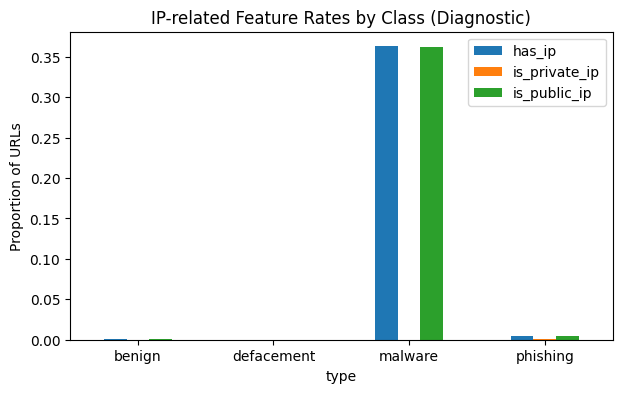

In [8]:
ip_diagnostic = data.groupby('type')[['has_ip', 'is_private_ip', 'is_public_ip']].mean()
print(ip_diagnostic)

ip_diagnostic.plot(kind='bar', figsize=(7,4))
plt.title("IP-related Feature Rates by Class (Diagnostic)")
plt.ylabel("Proportion of URLs")
plt.xticks(rotation=0)
plt.show()

In [9]:
feature_cols = list(features_df.columns)

X = data[feature_cols]
y_raw = data['type']

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))
print("X shape:", X.shape, "| y shape:", y.shape)

Classes: {'benign': 0, 'defacement': 1, 'malware': 2, 'phishing': 3}
X shape: (651191, 22) | y shape: (651191,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 520952 | Test size: 130239


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.9442025814080268


In [12]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

XGBoost Accuracy: 0.9312571503159576


In [13]:
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

print("\n=== XGBoost ===")
print(classification_report(y_test, xgb_preds, target_names=le.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

      benign       0.96      0.97      0.96     85621
  defacement       0.96      0.97      0.97     19292
     malware       0.99      0.93      0.96      6504
    phishing       0.85      0.80      0.83     18822

    accuracy                           0.94    130239
   macro avg       0.94      0.92      0.93    130239
weighted avg       0.94      0.94      0.94    130239


=== XGBoost ===
              precision    recall  f1-score   support

      benign       0.98      0.93      0.95     85621
  defacement       0.95      0.99      0.97     19292
     malware       0.95      0.94      0.95      6504
    phishing       0.73      0.90      0.80     18822

    accuracy                           0.93    130239
   macro avg       0.90      0.94      0.92    130239
weighted avg       0.94      0.93      0.93    130239



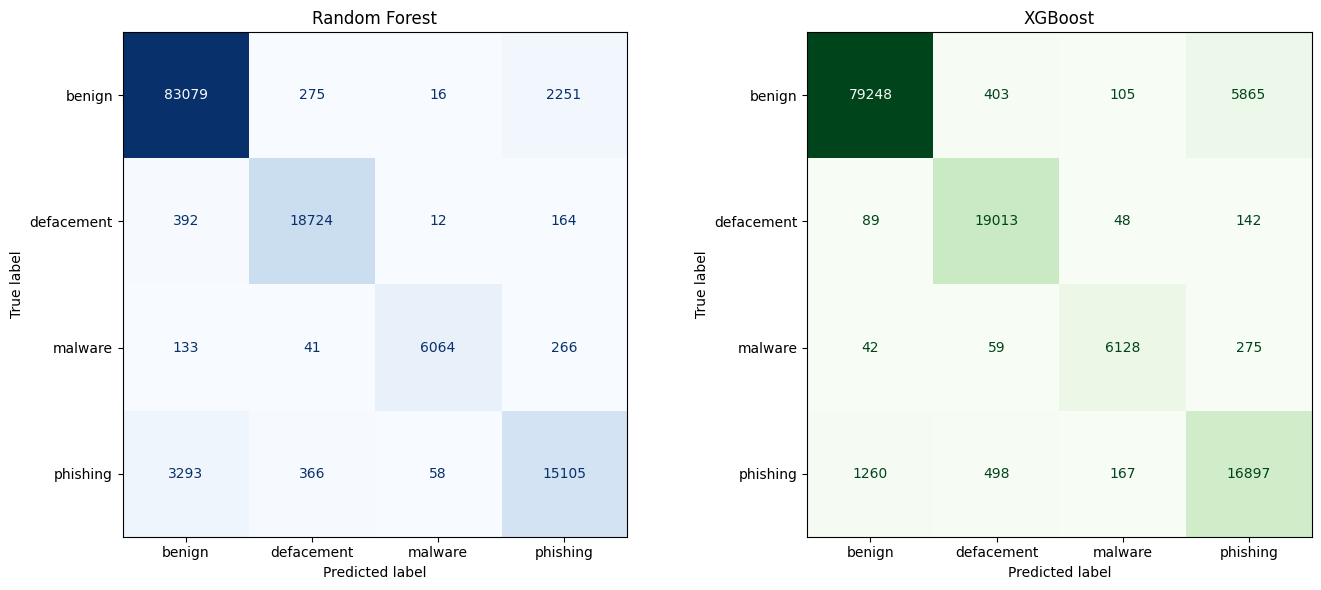

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Random Forest")

cm_xgb = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

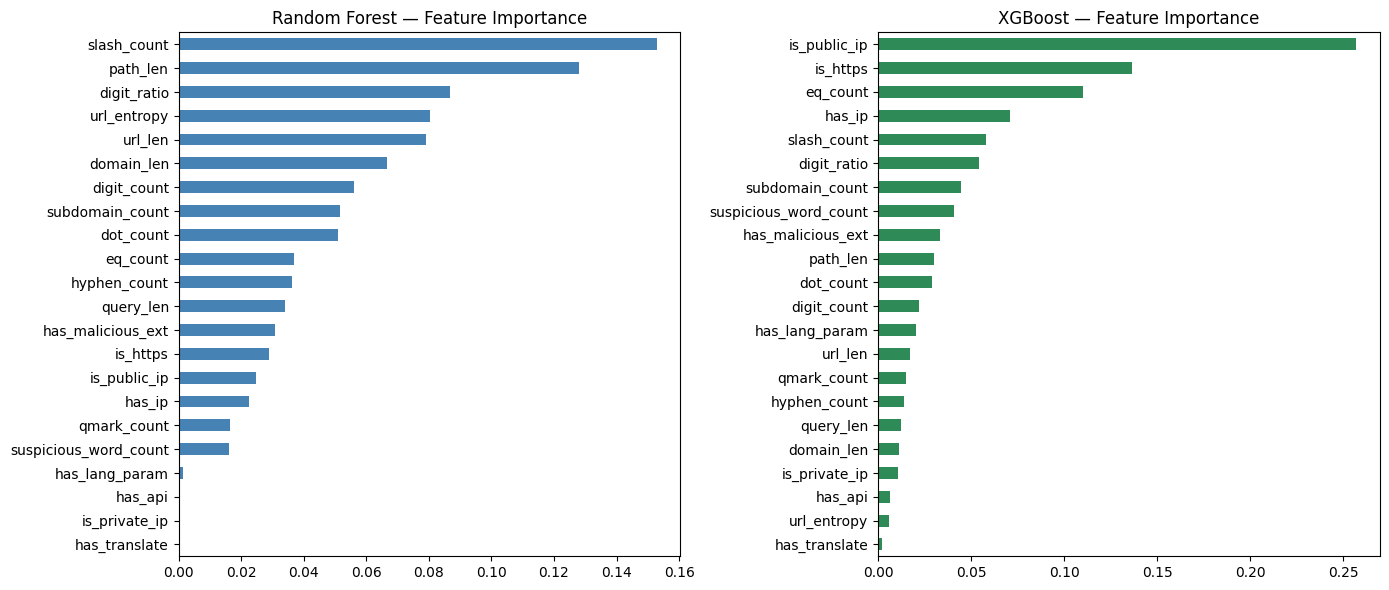

In [15]:
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Random Forest — Feature Importance")
axes[0].invert_yaxis()

xgb_importance.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title("XGBoost — Feature Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
best_model = xgb_model if accuracy_score(y_test, xgb_preds) >= accuracy_score(y_test, rf_preds) else rf_model
best_name = "xgboost" if best_model is xgb_model else "random_forest"

joblib.dump(best_model, f"/kaggle/working/best_model_{best_name}.pkl")
joblib.dump(le, "/kaggle/working/label_encoder.pkl")
joblib.dump(feature_cols, "/kaggle/working/feature_columns.pkl")

print(f"Saved: /kaggle/working/best_model_{best_name}.pkl")

Saved: /kaggle/working/best_model_random_forest.pkl
